In [49]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt


In [50]:
x = 6 * np.random.rand(200,1) - 3
y = 0.5 * x**2 + x + 2 + np.random.randn(200,1)

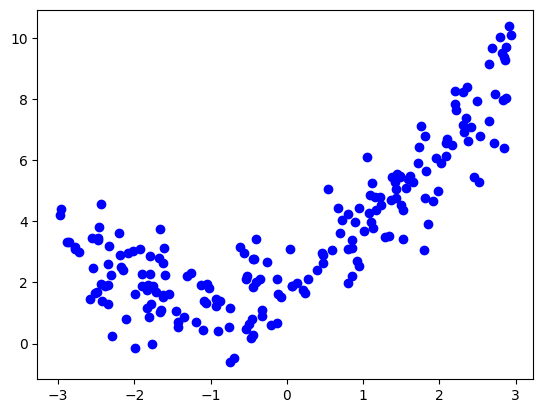

In [51]:
plt.scatter(x,y, color='blue')

In [52]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

In [53]:
lrr = LinearRegression()
lrr.fit(x_train,y_train)

y_pred = lrr.predict(x_test)

In [54]:
r2_score(y_test,y_pred)

0.44909450413122687

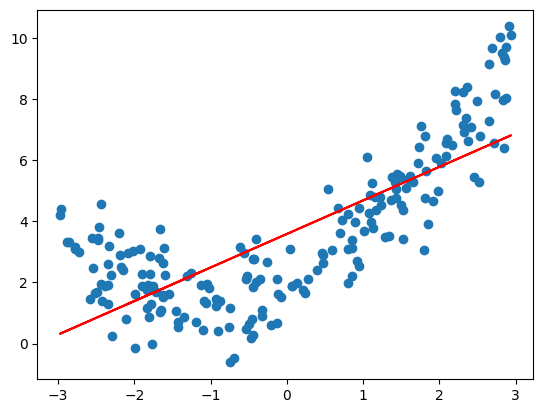

In [55]:
plt.scatter(x,y)
plt.plot(x,lrr.predict(x),color='red')
plt.show()

# apply the polynomail feature

In [73]:
poly = PolynomialFeatures(degree=2,include_bias=False)

x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.fit_transform(x_test)


In [74]:
print(x_train[0])
print(x_train_trans[0])

[1.11034877]
[1.11034877 1.23287439]


In [75]:
lrr.fit(x_train_trans,y_train)
y_pred = lrr.predict(x_test_trans)



In [76]:
r2_score(y_test,y_pred)

0.8156587311101919

In [77]:
x_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lrr.predict(X_new_poly)

print(lrr.coef_)
print(lrr.intercept_)

[[1.02808166 0.48024844]]
[2.08268451]


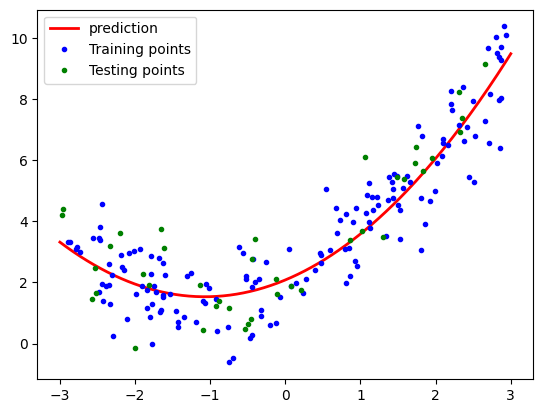

In [61]:
plt.plot(x_new,y_new,color='red',linewidth=2,label='prediction')
plt.plot(x_train, y_train, "b.",label='Training points')
plt.plot(x_test, y_test, "g.",label='Testing points')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1120: RuntimeWarning: overflow encountered in square
  temp **= 2
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


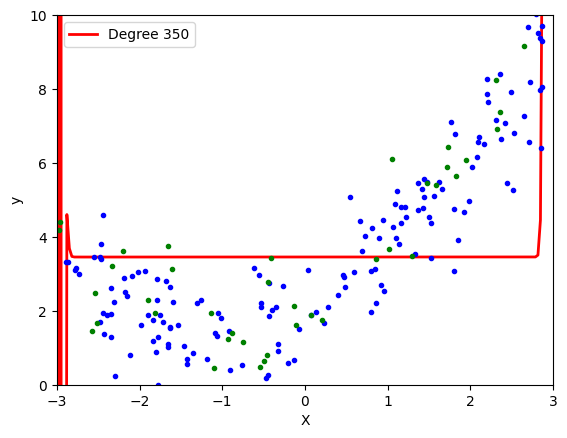

In [63]:
from sklearn.preprocessing import StandardScaler

def polynomial_regression(degree):
    x_new=np.linspace(-3, 3, 100).reshape(100, 1)
    x_new_poly = poly.transform(X_new)

    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])
    polynomial_regression.fit(x, y)
    y_newbig = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_newbig,'r', label="Degree " + str(degree), linewidth=2)

    plt.plot(x_train, y_train, "b.", linewidth=3)
    plt.plot(x_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()
polynomial_regression(350)

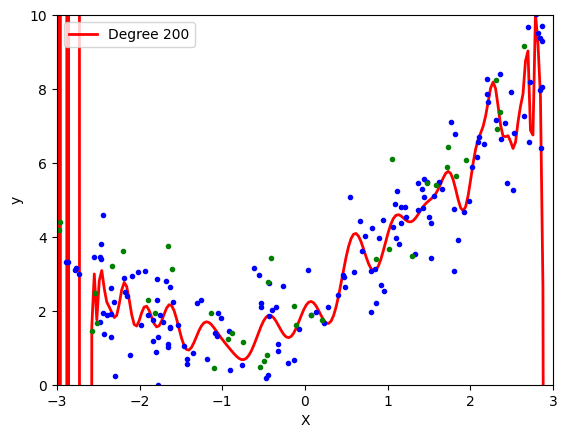

In [68]:
polynomial_regression(200)